### plotting the model and the data with the fit

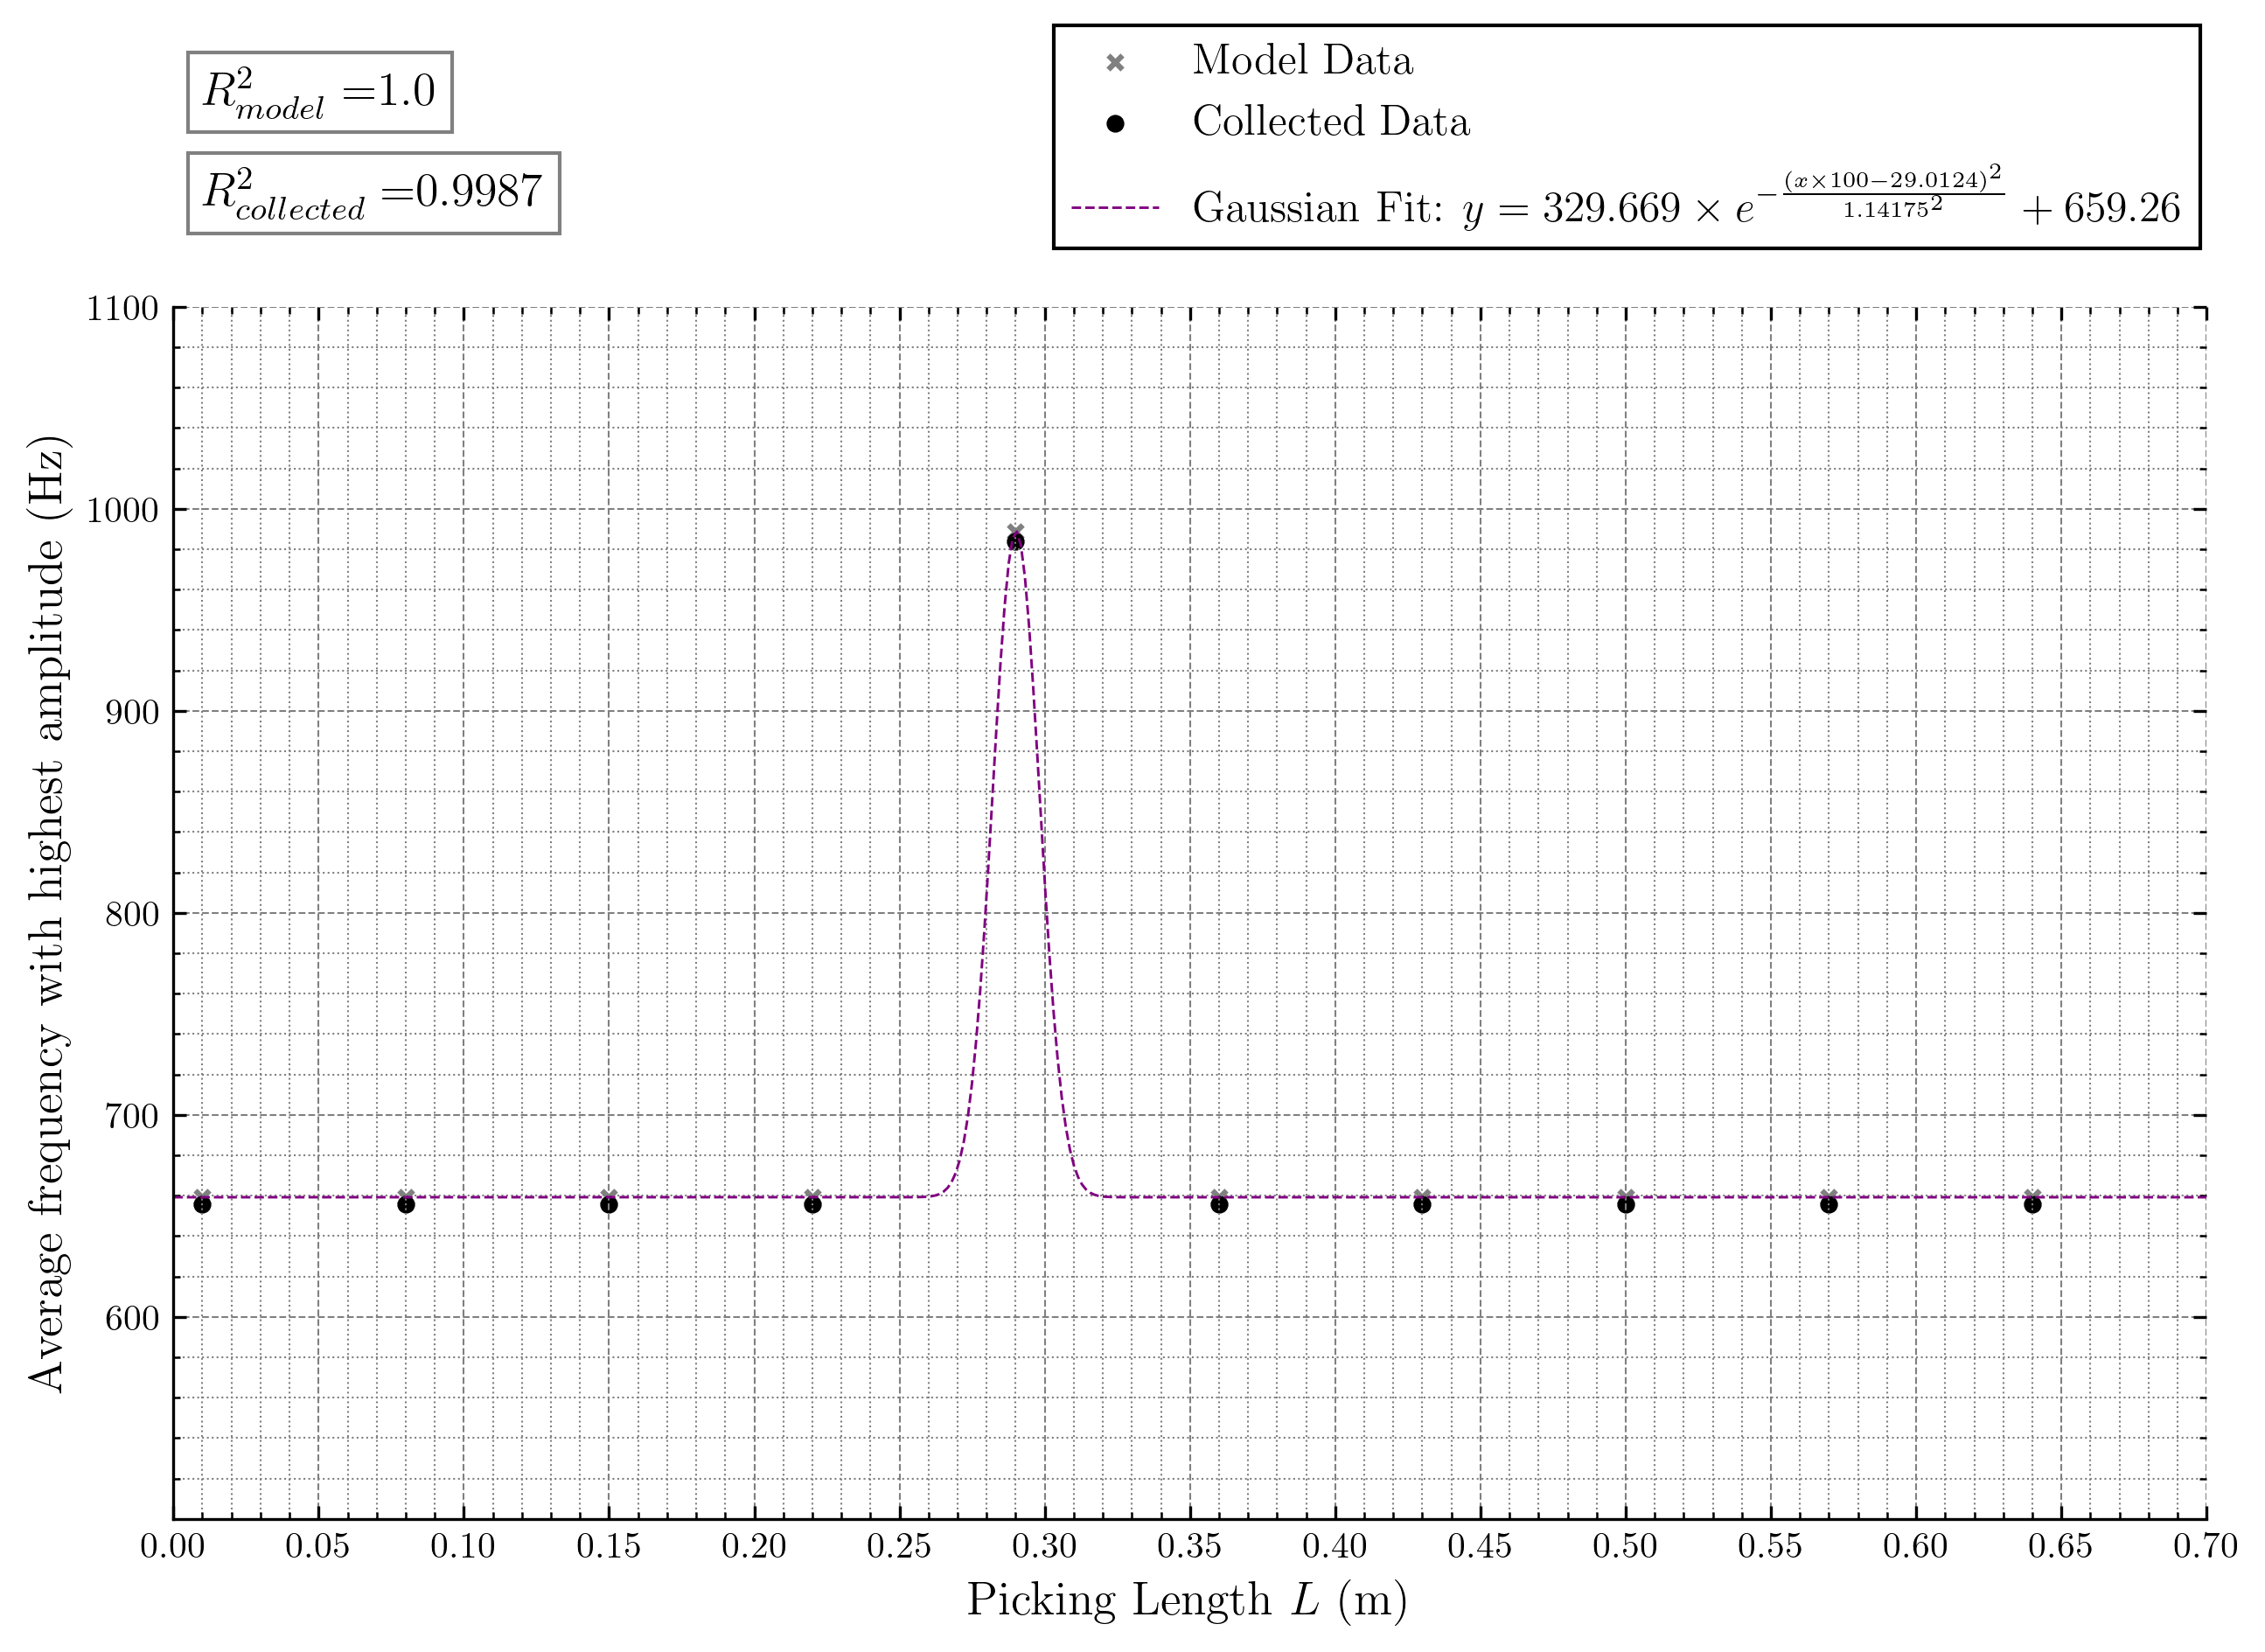

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use LaTeX-compatible font
from matplotlib import rc
# Use LaTeX-compatible font
matplotlib.font_manager.fontManager.addfont('latinmodern-math.otf')
plt.rcParams["font.family"] = "Latin Modern Math"
plt.rcParams["mathtext.fontset"] = "cm"
rc('text', usetex=True)

# Load the model and collected data from CSV files
model_data_df = pd.read_csv('model_data.csv')
collected_data_df = pd.read_csv('collected_data.csv')

# Extract relevant data
model_x = model_data_df['Picking Length L (m)']
model_y = model_data_df['Average frequency with highest intensity (Hz)']
collected_x = collected_data_df['Picking Length L (m)']
collected_y = collected_data_df['Average frequency with highest intensity (Hz)']

# Define the Gaussian function
def gaussian(x):
    return 329.669 * np.exp(-((x * 100 - 29.0124) ** 2) / (1.14175 ** 2)) + 659.26

# Generate x values for plotting the Gaussian curve
x_values = np.linspace(0, 0.7, 500)

# Generate y values based on the Gaussian function
y_values = gaussian(x_values)

# ---------- LaTeX/pgfplots Style ----------
# Create the scatter plot with specified styles and LaTeX/pgfplots adaptations
plt.figure(figsize=(10, 6), dpi=300)

# Scatter plots
plt.scatter(model_x, model_y, label='Model Data', marker='x', color='grey', s=15)
plt.scatter(collected_x, collected_y, label='Collected Data', marker='o', color='black', s=15)

# Gaussian line of best fit
gaussian_eq = r"$y = 329.669 \times e^{-\frac{(x \times 100 - 29.0124)^2}{1.14175^2}} + 659.26$"
plt.plot(x_values, y_values, label=f'Gaussian Fit: {gaussian_eq}', linestyle='--', color='purple', linewidth=0.7)


# Axis Labels and Title
plt.xlabel('Picking Length $L$ (m)', fontsize=13)
plt.ylabel('Average frequency with highest amplitude (Hz)', fontsize=13)
# plt.title('Comparison of Model and Collected Data', fontsize=14)

# Axis limits
plt.xlim(0, 0.7)
plt.ylim(500, 1100)

# Major and Minor Ticks
plt.xticks(np.arange(0, 0.71, 0.05))
plt.yticks(np.arange(600, 1101, 100))
plt.minorticks_on()

# Grid settings to mimic LaTeX style
plt.grid(which='both', linestyle='--', linewidth='0.5', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')

# Remove top and right spines to mimic LaTeX/pgfplots style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)

# Ticks inside the plot area
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

# Legend
plt.legend(fontsize=12, edgecolor='black', facecolor='white', framealpha=1, 
           fancybox=False, loc='upper center', bbox_to_anchor=(0.715, 1.25))


# correlation
model_r2 = 1.0
collected_r2 = 0.9987
plt.text(0.01, 1200, r'$R^2_{model}=$' + str(model_r2), fontsize=13, 
         bbox=dict(facecolor='white', edgecolor='grey', boxstyle='square,pad=0.3'))
plt.text(0.01, 1150, r'$R^2_{collected}=$' + str(collected_r2), fontsize=13, 
         bbox=dict(facecolor='white', edgecolor='grey', boxstyle='square,pad=0.3'))


# Show the plot
plt.show()